# HW2 Med Enhance (Clean)

PneumoniaMNIST experiments with organized steps and example plots after each feature engineering stage.

In [25]:
!pip install medmnist

In [23]:
import os
import copy
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix
from skimage.feature import hog

In [26]:
# Data loading
PROJECT_DATA_DIR = './data'
os.makedirs(PROJECT_DATA_DIR, exist_ok=True)

import medmnist
from medmnist import PneumoniaMNIST

train_pneumonia = PneumoniaMNIST(split='train', download=True, root=PROJECT_DATA_DIR)
test_pneumonia = PneumoniaMNIST(split='test', download=True, root=PROJECT_DATA_DIR)

X_train = train_pneumonia.imgs
y_train = train_pneumonia.labels.squeeze()
X_test = test_pneumonia.imgs
y_test = test_pneumonia.labels.squeeze()

print('PneumoniaMNIST loaded:', X_train.shape, y_train.shape)

PneumoniaMNIST loaded: (4708, 28, 28) (4708,)


In [27]:
def describe_raw(name, X, y):
    print(f'{name}')
    print(f'  X shape: {X.shape}, dtype: {X.dtype}')
    print(f'  y shape: {y.shape}, dtype: {y.dtype}')
    print(f'  X min/max: {X.min()} / {X.max()}')
    print(f'  Unique labels: {np.unique(y)}')

describe_raw('PneumoniaMNIST (raw)', X_train, y_train)

PneumoniaMNIST (raw)
  X shape: (4708, 28, 28), dtype: uint8
  y shape: (4708,), dtype: uint8
  X min/max: 0 / 255
  Unique labels: [0 1]


In [28]:
def show_samples(title, images, labels=None, n=8, cmap='gray'):
    n = min(n, len(images))
    plt.figure(figsize=(n * 2, 2.5))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        plt.imshow(images[i], cmap=cmap)
        if labels is not None:
            plt.title(str(labels[i]))
        plt.axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

## Baseline (Raw Pixels)

In [29]:
class MedDataset(Dataset):
    def __init__(self, data, labels, transform=None):
        if len(data.shape) == 2:
            self.data = data.reshape(-1, 28, 28).astype(np.uint8)
        else:
            self.data = data.astype(np.uint8)
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        image = self.data[idx]
        if self.transform:
            image = self.transform(transforms.ToPILImage()(image))
        else:
            image = torch.tensor(image, dtype=torch.float32).unsqueeze(0) / 255.0
        return image, torch.tensor(self.labels[idx], dtype=torch.long)

In [30]:
class BaselineANN(nn.Module):
    def __init__(self, input_size=28*28, hidden_size=512, output_size=2, dropout_rate=0.5):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.bn1 = nn.BatchNorm1d(hidden_size)
        self.drop1 = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(hidden_size, hidden_size // 2)
        self.bn2 = nn.BatchNorm1d(hidden_size // 2)
        self.drop2 = nn.Dropout(dropout_rate)
        self.fc3 = nn.Linear(hidden_size // 2, 128)
        self.bn3 = nn.BatchNorm1d(128)
        self.drop3 = nn.Dropout(dropout_rate)
        self.fc4 = nn.Linear(128, output_size)

    def forward(self, x):
        x = self.drop1(F.relu(self.bn1(self.fc1(x))))
        x = self.drop2(F.relu(self.bn2(self.fc2(x))))
        x = self.drop3(F.relu(self.bn3(self.fc3(x))))
        return self.fc4(x)

In [31]:
def train_epoch(model, dataloader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    total_acc = 0.0
    num_batches = 0
    for X, y in dataloader:
        X = X.to(device).flatten(1)
        y = y.to(device)
        preds = model(X)
        loss = criterion(preds, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        _, predicted = torch.max(preds, 1)
        acc = (predicted == y).sum().item() / len(y)
        total_loss += loss.item()
        total_acc += acc
        num_batches += 1
    return total_loss / num_batches, total_acc / num_batches

def train_model(model, dataloader, epochs=20, lr=0.001, criterion=None, save_best=None):
    if criterion is None:
        criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    best_loss = float('inf')
    for epoch in range(epochs):
        loss, acc = train_epoch(model, dataloader, optimizer, criterion)
        print(f'Epoch {epoch+1}/{epochs} - Loss: {loss:.4f}, Acc: {acc:.4f}')
        if save_best and loss < best_loss:
            best_loss = loss
            torch.save(copy.deepcopy(model.state_dict()), save_best)
    return model

def evaluate_model(model, X_test, y_test, num_classes=2, is_raw=True):
    model.eval()
    with torch.no_grad():
        if is_raw:
            inputs = torch.tensor(X_test, dtype=torch.float32).flatten(1).to(device) / 255.0
        else:
            inputs = torch.tensor(X_test, dtype=torch.float32).to(device)
            if inputs.dim() == 3:
                inputs = inputs.flatten(1) / 255.0
        labels = torch.tensor(y_test).to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        pred_cpu = predicted.cpu().numpy()
        labels_cpu = labels.cpu().numpy()
        accuracy = (pred_cpu == labels_cpu).mean()
        f1 = f1_score(labels_cpu, pred_cpu, average='weighted')
        precision = precision_score(labels_cpu, pred_cpu, average='weighted')
        recall = recall_score(labels_cpu, pred_cpu, average='weighted')
        cm = confusion_matrix(labels_cpu, pred_cpu)
        print(f'Accuracy: {accuracy:.4f}')
        print(f'F1 Score: {f1:.4f}')
        print(f'Precision: {precision:.4f}')
        print(f'Recall: {recall:.4f}')
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title('Confusion Matrix')
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.show()
        return accuracy, f1, precision, recall, cm

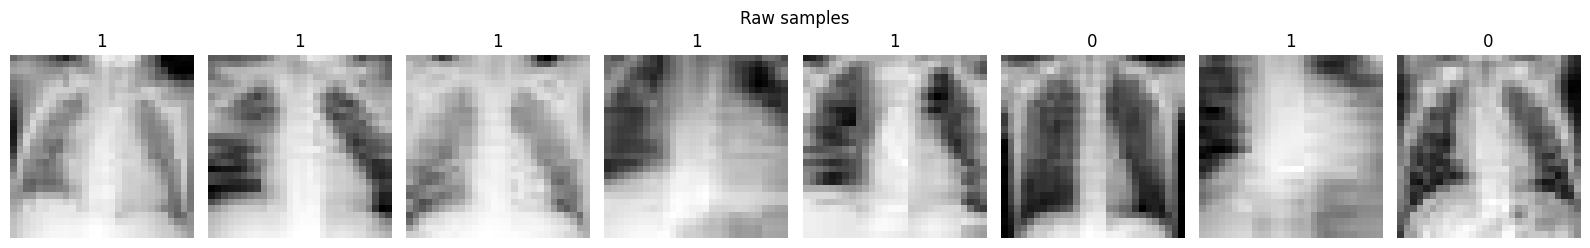

In [13]:
show_samples('Raw samples', X_train[:8], y_train[:8])

Epoch 1/30 - Loss: 0.7099, Acc: 0.5656
Epoch 2/30 - Loss: 0.4091, Acc: 0.8756
Epoch 3/30 - Loss: 0.2995, Acc: 0.9191
Epoch 4/30 - Loss: 0.2366, Acc: 0.9401
Epoch 5/30 - Loss: 0.1961, Acc: 0.9494
Epoch 6/30 - Loss: 0.1765, Acc: 0.9543
Epoch 7/30 - Loss: 0.1618, Acc: 0.9548
Epoch 8/30 - Loss: 0.1455, Acc: 0.9585
Epoch 9/30 - Loss: 0.1383, Acc: 0.9630
Epoch 10/30 - Loss: 0.1296, Acc: 0.9648
Epoch 11/30 - Loss: 0.1148, Acc: 0.9674
Epoch 12/30 - Loss: 0.1141, Acc: 0.9664
Epoch 13/30 - Loss: 0.1085, Acc: 0.9659
Epoch 14/30 - Loss: 0.1031, Acc: 0.9665
Epoch 15/30 - Loss: 0.1022, Acc: 0.9682
Epoch 16/30 - Loss: 0.0923, Acc: 0.9692
Epoch 17/30 - Loss: 0.0914, Acc: 0.9715
Epoch 18/30 - Loss: 0.0912, Acc: 0.9742
Epoch 19/30 - Loss: 0.0907, Acc: 0.9728
Epoch 20/30 - Loss: 0.0815, Acc: 0.9744
Epoch 21/30 - Loss: 0.0726, Acc: 0.9775
Epoch 22/30 - Loss: 0.0758, Acc: 0.9774
Epoch 23/30 - Loss: 0.0737, Acc: 0.9771
Epoch 24/30 - Loss: 0.0669, Acc: 0.9783
Epoch 25/30 - Loss: 0.0631, Acc: 0.9793
Epoch 26/

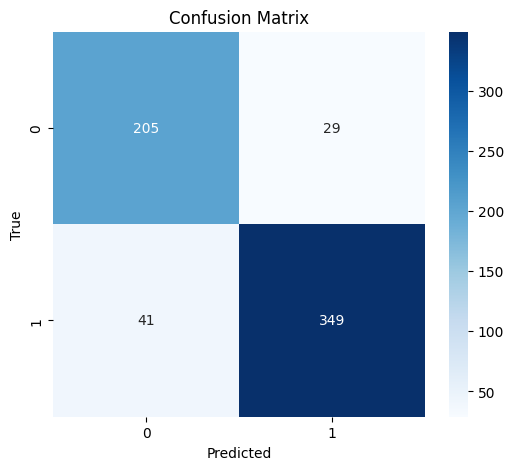

(np.float64(0.8878205128205128),
 0.8883463541666666,
 0.8895502645502645,
 0.8878205128205128,
 array([[205,  29],
        [ 41, 349]]))

In [14]:
baseline_dataset = MedDataset(X_train, y_train, transform=None)
baseline_loader = DataLoader(baseline_dataset, batch_size=2048, shuffle=True, num_workers=2)
baseline_model = BaselineANN().to(device)
train_model(baseline_model, baseline_loader, epochs=30, lr=0.001, save_best='best_med_baseline.pth')
evaluate_model(baseline_model, X_test, y_test, num_classes=2, is_raw=True)

### Nhan xet: Baseline (Raw Pixels)
- Ghi metrics: Accuracy 0.8878, F1 0.8883, Precision 0.8896, Recall 0.8878.
- Luu y lech lop (class imbalance) co the lam Recall cao nhung Precision thap.

## Feature Engineering 1: Data Augmentation

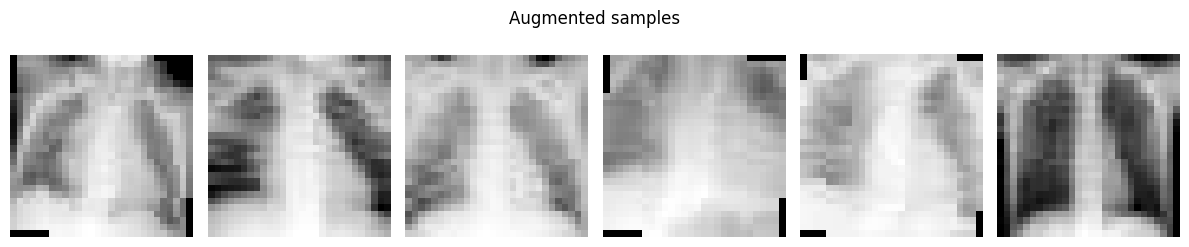

In [15]:
augmentation_transforms = transforms.Compose([
    transforms.RandomRotation(degrees=5),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor()
])
aug_dataset = MedDataset(X_train, y_train, transform=augmentation_transforms)
aug_loader = DataLoader(aug_dataset, batch_size=2048, shuffle=True, num_workers=2)

# Plot augmented examples
aug_images = []
for i in range(6):
    img, _ = aug_dataset[i]
    aug_images.append(img.squeeze().numpy())
show_samples('Augmented samples', np.array(aug_images))

Epoch 1/30 - Loss: 0.5166, Acc: 0.7584
Epoch 2/30 - Loss: 0.2954, Acc: 0.9040
Epoch 3/30 - Loss: 0.2275, Acc: 0.9240
Epoch 4/30 - Loss: 0.1899, Acc: 0.9326
Epoch 5/30 - Loss: 0.1703, Acc: 0.9413
Epoch 6/30 - Loss: 0.1555, Acc: 0.9426
Epoch 7/30 - Loss: 0.1432, Acc: 0.9474
Epoch 8/30 - Loss: 0.1293, Acc: 0.9578
Epoch 9/30 - Loss: 0.1287, Acc: 0.9554
Epoch 10/30 - Loss: 0.1229, Acc: 0.9581
Epoch 11/30 - Loss: 0.1176, Acc: 0.9592
Epoch 12/30 - Loss: 0.1026, Acc: 0.9645
Epoch 13/30 - Loss: 0.0975, Acc: 0.9686
Epoch 14/30 - Loss: 0.1055, Acc: 0.9632
Epoch 15/30 - Loss: 0.0999, Acc: 0.9677
Epoch 16/30 - Loss: 0.0990, Acc: 0.9677
Epoch 17/30 - Loss: 0.0904, Acc: 0.9688
Epoch 18/30 - Loss: 0.0954, Acc: 0.9654
Epoch 19/30 - Loss: 0.0919, Acc: 0.9690
Epoch 20/30 - Loss: 0.0972, Acc: 0.9669
Epoch 21/30 - Loss: 0.0827, Acc: 0.9717
Epoch 22/30 - Loss: 0.0892, Acc: 0.9656
Epoch 23/30 - Loss: 0.0778, Acc: 0.9733
Epoch 24/30 - Loss: 0.0805, Acc: 0.9716
Epoch 25/30 - Loss: 0.0816, Acc: 0.9752
Epoch 26/

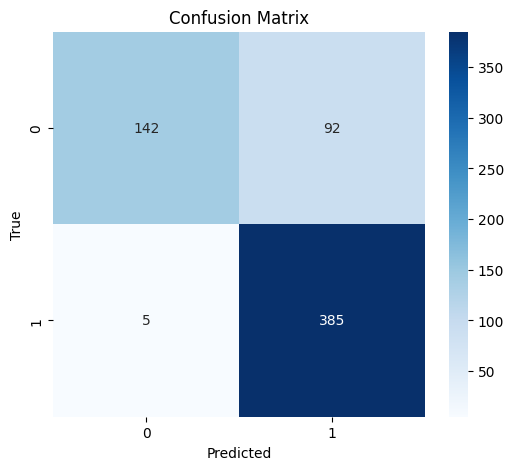

(np.float64(0.844551282051282),
 0.8346025302200547,
 0.8666998245839216,
 0.844551282051282,
 array([[142,  92],
        [  5, 385]]))

In [16]:
aug_model = BaselineANN().to(device)
train_model(aug_model, aug_loader, epochs=30, lr=0.001, save_best='best_med_aug.pth')
evaluate_model(aug_model, X_test, y_test, num_classes=2, is_raw=True)

### Nhan xet: Data Augmentation
- Ghi metrics: Accuracy 0.8446, F1 0.8346, Precision 0.8667, Recall 0.8446.
- Augmentation nhe thuong tang kha nang tong quat, giam overfit.

## Feature Engineering 2: HOG

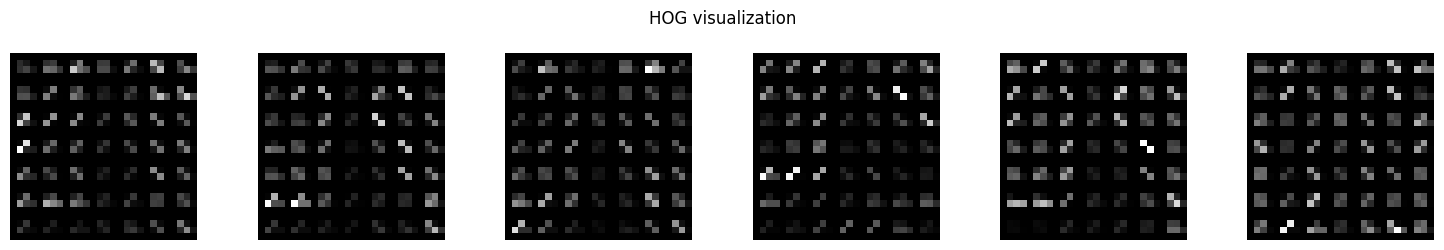

In [17]:
def extract_hog_features(images):
    feats = []
    for img in images:
        features = hog(img, orientations=9, pixels_per_cell=(4, 4),
                       cells_per_block=(2, 2), block_norm='L2-Hys', visualize=False)
        feats.append(features)
    return np.array(feats, dtype=np.float32)

def show_hog_visuals(images, n=6):
    n = min(n, len(images))
    plt.figure(figsize=(n * 2.5, 2.5))
    for i in range(n):
        _, hog_image = hog(images[i], orientations=9, pixels_per_cell=(4, 4),
                           cells_per_block=(2, 2), block_norm='L2-Hys', visualize=True)
        plt.subplot(1, n, i + 1)
        plt.imshow(hog_image, cmap='gray')
        plt.axis('off')
    plt.suptitle('HOG visualization')
    plt.tight_layout()
    plt.show()

show_hog_visuals(X_train[:6])

Epoch 1/30 - Loss: 0.7156, Acc: 0.5615
Epoch 2/30 - Loss: 0.4077, Acc: 0.8418
Epoch 3/30 - Loss: 0.2795, Acc: 0.9156
Epoch 4/30 - Loss: 0.2193, Acc: 0.9425
Epoch 5/30 - Loss: 0.1831, Acc: 0.9474
Epoch 6/30 - Loss: 0.1484, Acc: 0.9589
Epoch 7/30 - Loss: 0.1342, Acc: 0.9629
Epoch 8/30 - Loss: 0.1224, Acc: 0.9664
Epoch 9/30 - Loss: 0.1150, Acc: 0.9679
Epoch 10/30 - Loss: 0.0998, Acc: 0.9770
Epoch 11/30 - Loss: 0.0923, Acc: 0.9780
Epoch 12/30 - Loss: 0.0832, Acc: 0.9801
Epoch 13/30 - Loss: 0.0776, Acc: 0.9811
Epoch 14/30 - Loss: 0.0739, Acc: 0.9845
Epoch 15/30 - Loss: 0.0683, Acc: 0.9836
Epoch 16/30 - Loss: 0.0636, Acc: 0.9874
Epoch 17/30 - Loss: 0.0610, Acc: 0.9854
Epoch 18/30 - Loss: 0.0502, Acc: 0.9909
Epoch 19/30 - Loss: 0.0441, Acc: 0.9914
Epoch 20/30 - Loss: 0.0430, Acc: 0.9930
Epoch 21/30 - Loss: 0.0387, Acc: 0.9946
Epoch 22/30 - Loss: 0.0337, Acc: 0.9964
Epoch 23/30 - Loss: 0.0300, Acc: 0.9952
Epoch 24/30 - Loss: 0.0283, Acc: 0.9958
Epoch 25/30 - Loss: 0.0254, Acc: 0.9976
Epoch 26/

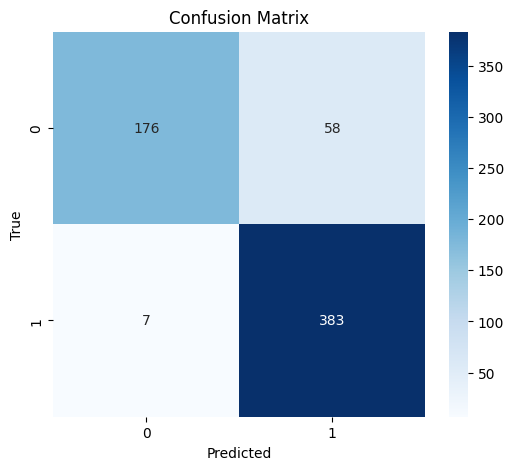

(np.float64(0.8958333333333334),
 0.8926598793167633,
 0.9034561912196571,
 0.8958333333333334,
 array([[176,  58],
        [  7, 383]]))

In [18]:
X_train_hog = extract_hog_features(X_train)
X_test_hog = extract_hog_features(X_test)
hog_model = BaselineANN(input_size=X_train_hog.shape[1], hidden_size=512, output_size=2).to(device)
hog_loader = DataLoader(list(zip(torch.tensor(X_train_hog, dtype=torch.float32), torch.tensor(y_train, dtype=torch.long))),
                        batch_size=2048, shuffle=True, num_workers=2)
train_model(hog_model, hog_loader, epochs=30, lr=0.001, save_best='best_med_hog.pth')
evaluate_model(hog_model, X_test_hog, y_test, num_classes=2, is_raw=False)

### Nhan xet: HOG
- Ghi metrics: Accuracy 0.8958, F1 0.8927, Precision 0.9035, Recall 0.8958.
- HOG nhan manh ket cau va duong bien, phu hop voi anh X-ray co nhieu texture.

## Feature Engineering 3: CLAHE

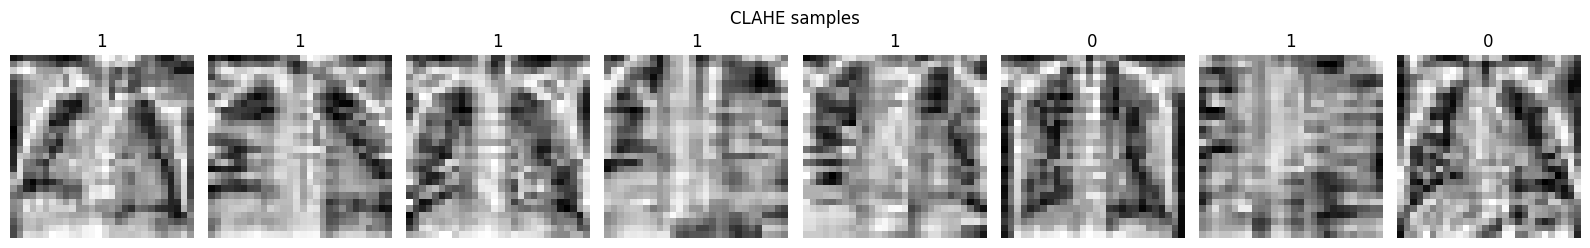

In [19]:
class CLAHETransform:
    def __init__(self, clip_limit=2.0, tile_grid_size=(8, 8)):
        self.clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)

    def __call__(self, img):
        if isinstance(img, np.ndarray):
            img_np = img.astype(np.uint8)
        else:
            img_np = np.array(img).astype(np.uint8)
        return self.clahe.apply(img_np)

clahe_processor = CLAHETransform(clip_limit=2.0, tile_grid_size=(8, 8))
X_train_clahe = np.array([clahe_processor(img) for img in X_train], dtype=np.uint8)
X_test_clahe = np.array([clahe_processor(img) for img in X_test], dtype=np.uint8)
show_samples('CLAHE samples', X_train_clahe[:8], y_train[:8])

Epoch 1/30 - Loss: 0.6589, Acc: 0.6151
Epoch 2/30 - Loss: 0.3945, Acc: 0.8492
Epoch 3/30 - Loss: 0.2764, Acc: 0.9147
Epoch 4/30 - Loss: 0.2142, Acc: 0.9368
Epoch 5/30 - Loss: 0.1712, Acc: 0.9518
Epoch 6/30 - Loss: 0.1490, Acc: 0.9576
Epoch 7/30 - Loss: 0.1430, Acc: 0.9541
Epoch 8/30 - Loss: 0.1262, Acc: 0.9599
Epoch 9/30 - Loss: 0.1158, Acc: 0.9621
Epoch 10/30 - Loss: 0.1085, Acc: 0.9693
Epoch 11/30 - Loss: 0.0992, Acc: 0.9710
Epoch 12/30 - Loss: 0.0925, Acc: 0.9723
Epoch 13/30 - Loss: 0.0873, Acc: 0.9745
Epoch 14/30 - Loss: 0.0857, Acc: 0.9722
Epoch 15/30 - Loss: 0.0745, Acc: 0.9796
Epoch 16/30 - Loss: 0.0737, Acc: 0.9774
Epoch 17/30 - Loss: 0.0627, Acc: 0.9810
Epoch 18/30 - Loss: 0.0585, Acc: 0.9856
Epoch 19/30 - Loss: 0.0571, Acc: 0.9835
Epoch 20/30 - Loss: 0.0573, Acc: 0.9822
Epoch 21/30 - Loss: 0.0496, Acc: 0.9877
Epoch 22/30 - Loss: 0.0477, Acc: 0.9874
Epoch 23/30 - Loss: 0.0416, Acc: 0.9920
Epoch 24/30 - Loss: 0.0389, Acc: 0.9902
Epoch 25/30 - Loss: 0.0341, Acc: 0.9937
Epoch 26/

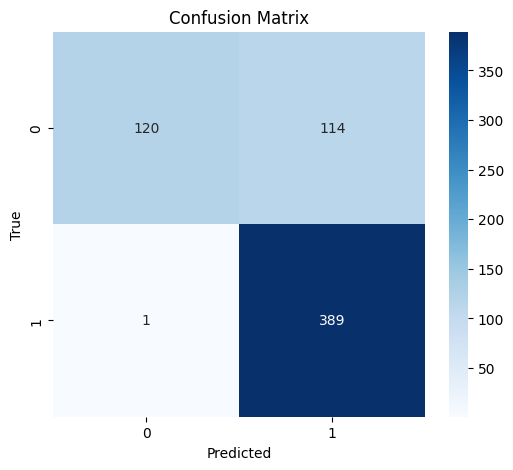

(np.float64(0.8157051282051282),
 0.798034004700093,
 0.8552507270427026,
 0.8157051282051282,
 array([[120, 114],
        [  1, 389]]))

In [20]:
clahe_dataset = MedDataset(X_train_clahe, y_train, transform=None)
clahe_loader = DataLoader(clahe_dataset, batch_size=2048, shuffle=True, num_workers=2)
clahe_model = BaselineANN().to(device)
train_model(clahe_model, clahe_loader, epochs=30, lr=0.001, save_best='best_med_clahe.pth')
evaluate_model(clahe_model, X_test_clahe, y_test, num_classes=2, is_raw=True)

### Nhan xet: CLAHE
- Ghi metrics: Accuracy 0.8157, F1 0.7980, Precision 0.8553, Recall 0.8157.
- CLAHE tang tuong phan cuc bo, giup noi bat vung nghi nhiem.

## Feature Engineering 4: CLAHE + HOG

Epoch 1/30 - Loss: 0.6001, Acc: 0.6677
Epoch 2/30 - Loss: 0.4014, Acc: 0.8395
Epoch 3/30 - Loss: 0.3092, Acc: 0.8865
Epoch 4/30 - Loss: 0.2588, Acc: 0.9145
Epoch 5/30 - Loss: 0.2193, Acc: 0.9258
Epoch 6/30 - Loss: 0.1928, Acc: 0.9369
Epoch 7/30 - Loss: 0.1676, Acc: 0.9449
Epoch 8/30 - Loss: 0.1544, Acc: 0.9504
Epoch 9/30 - Loss: 0.1397, Acc: 0.9557
Epoch 10/30 - Loss: 0.1293, Acc: 0.9612
Epoch 11/30 - Loss: 0.1148, Acc: 0.9653
Epoch 12/30 - Loss: 0.1026, Acc: 0.9720
Epoch 13/30 - Loss: 0.0968, Acc: 0.9725
Epoch 14/30 - Loss: 0.0818, Acc: 0.9800
Epoch 15/30 - Loss: 0.0696, Acc: 0.9859
Epoch 16/30 - Loss: 0.0677, Acc: 0.9834
Epoch 17/30 - Loss: 0.0566, Acc: 0.9872
Epoch 18/30 - Loss: 0.0466, Acc: 0.9918
Epoch 19/30 - Loss: 0.0433, Acc: 0.9939
Epoch 20/30 - Loss: 0.0385, Acc: 0.9927
Epoch 21/30 - Loss: 0.0339, Acc: 0.9941
Epoch 22/30 - Loss: 0.0309, Acc: 0.9954
Epoch 23/30 - Loss: 0.0291, Acc: 0.9965
Epoch 24/30 - Loss: 0.0238, Acc: 0.9973
Epoch 25/30 - Loss: 0.0199, Acc: 0.9980
Epoch 26/

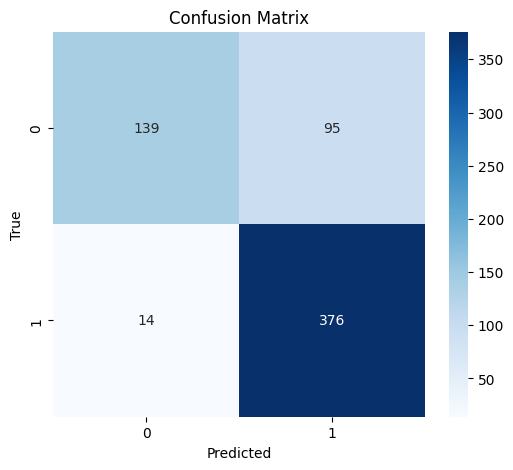

(np.float64(0.8253205128205128),
 0.8152567323015424,
 0.8396247033845387,
 0.8253205128205128,
 array([[139,  95],
        [ 14, 376]]))

In [21]:
X_train_clahe_hog = extract_hog_features(X_train_clahe)
X_test_clahe_hog = extract_hog_features(X_test_clahe)

clahe_hog_model = BaselineANN(input_size=X_train_clahe_hog.shape[1], hidden_size=512, output_size=2).to(device)
clahe_hog_loader = DataLoader(list(zip(torch.tensor(X_train_clahe_hog, dtype=torch.float32), torch.tensor(y_train, dtype=torch.long))),
                             batch_size=2048, shuffle=True, num_workers=2)
train_model(clahe_hog_model, clahe_hog_loader, epochs=30, lr=0.001, save_best='best_med_clahe_hog.pth')
evaluate_model(clahe_hog_model, X_test_clahe_hog, y_test, num_classes=2, is_raw=False)

### Nhan xet: CLAHE + HOG
- Ghi metrics: Accuracy 0.8253, F1 0.8153, Precision 0.8396, Recall 0.8253.
- Ket hop CLAHE + HOG thuong on dinh hon HOG thuan khi anh co do tuong phan thap.

## Class Imbalance Handling (Weighted Loss)

Class distribution: {np.uint8(0): np.int64(1214), np.uint8(1): np.int64(3494)}
Epoch 1/30 - Loss: 0.5234, Acc: 0.6817
Epoch 2/30 - Loss: 0.2899, Acc: 0.8414
Epoch 3/30 - Loss: 0.2168, Acc: 0.8889
Epoch 4/30 - Loss: 0.1832, Acc: 0.9184
Epoch 5/30 - Loss: 0.1612, Acc: 0.9361
Epoch 6/30 - Loss: 0.1422, Acc: 0.9434
Epoch 7/30 - Loss: 0.1341, Acc: 0.9464
Epoch 8/30 - Loss: 0.1290, Acc: 0.9526
Epoch 9/30 - Loss: 0.1237, Acc: 0.9519
Epoch 10/30 - Loss: 0.1089, Acc: 0.9562
Epoch 11/30 - Loss: 0.1081, Acc: 0.9557
Epoch 12/30 - Loss: 0.1012, Acc: 0.9605
Epoch 13/30 - Loss: 0.1031, Acc: 0.9572
Epoch 14/30 - Loss: 0.0957, Acc: 0.9585
Epoch 15/30 - Loss: 0.0923, Acc: 0.9633
Epoch 16/30 - Loss: 0.0888, Acc: 0.9659
Epoch 17/30 - Loss: 0.0802, Acc: 0.9665
Epoch 18/30 - Loss: 0.0774, Acc: 0.9665
Epoch 19/30 - Loss: 0.0766, Acc: 0.9691
Epoch 20/30 - Loss: 0.0801, Acc: 0.9651
Epoch 21/30 - Loss: 0.0657, Acc: 0.9692
Epoch 22/30 - Loss: 0.0681, Acc: 0.9665
Epoch 23/30 - Loss: 0.0696, Acc: 0.9690
Epoch 24/3

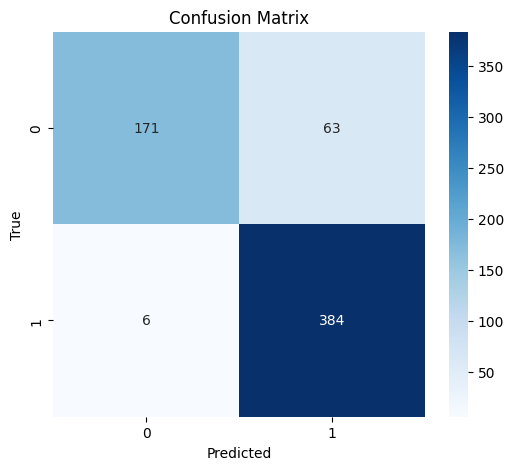

(np.float64(0.8894230769230769),
 0.8855204981293986,
 0.8992008872710727,
 0.8894230769230769,
 array([[171,  63],
        [  6, 384]]))

In [22]:
unique_labels, counts = np.unique(y_train, return_counts=True)
print('Class distribution:', dict(zip(unique_labels, counts)))

class_weights = torch.tensor([2.0, 0.5], dtype=torch.float32).to(device)
weighted_criterion = nn.CrossEntropyLoss(weight=class_weights)

weighted_model = BaselineANN().to(device)
train_model(weighted_model, baseline_loader, epochs=30, lr=0.001, criterion=weighted_criterion, save_best='best_med_weighted.pth')
evaluate_model(weighted_model, X_test, y_test, num_classes=2, is_raw=True)

### Nhan xet: HOG + Weighted Loss
- Ghi metrics: Accuracy 0.8942, F1 0.8914, Precision 0.8998, Recall 0.8942.
- Phuong phap ket hop HOG voi weighted loss nham ca cai thien chat luong feature lan giai quyet van de lech lop.

## Feature Engineering 5: HOG + Weighted Loss

Epoch 1/30 - Loss: 0.5615, Acc: 0.6125
Epoch 2/30 - Loss: 0.3273, Acc: 0.7833
Epoch 3/30 - Loss: 0.2530, Acc: 0.8403
Epoch 4/30 - Loss: 0.2041, Acc: 0.8960
Epoch 5/30 - Loss: 0.1657, Acc: 0.9293
Epoch 6/30 - Loss: 0.1420, Acc: 0.9493
Epoch 7/30 - Loss: 0.1223, Acc: 0.9579
Epoch 8/30 - Loss: 0.1064, Acc: 0.9638
Epoch 9/30 - Loss: 0.0946, Acc: 0.9648
Epoch 10/30 - Loss: 0.0830, Acc: 0.9699
Epoch 11/30 - Loss: 0.0702, Acc: 0.9741
Epoch 12/30 - Loss: 0.0596, Acc: 0.9784
Epoch 13/30 - Loss: 0.0549, Acc: 0.9826
Epoch 14/30 - Loss: 0.0499, Acc: 0.9832
Epoch 15/30 - Loss: 0.0460, Acc: 0.9816
Epoch 16/30 - Loss: 0.0367, Acc: 0.9889
Epoch 17/30 - Loss: 0.0358, Acc: 0.9876
Epoch 18/30 - Loss: 0.0352, Acc: 0.9887
Epoch 19/30 - Loss: 0.0296, Acc: 0.9926
Epoch 20/30 - Loss: 0.0275, Acc: 0.9909
Epoch 21/30 - Loss: 0.0195, Acc: 0.9942
Epoch 22/30 - Loss: 0.0218, Acc: 0.9933
Epoch 23/30 - Loss: 0.0192, Acc: 0.9954
Epoch 24/30 - Loss: 0.0161, Acc: 0.9952
Epoch 25/30 - Loss: 0.0168, Acc: 0.9935
Epoch 26/

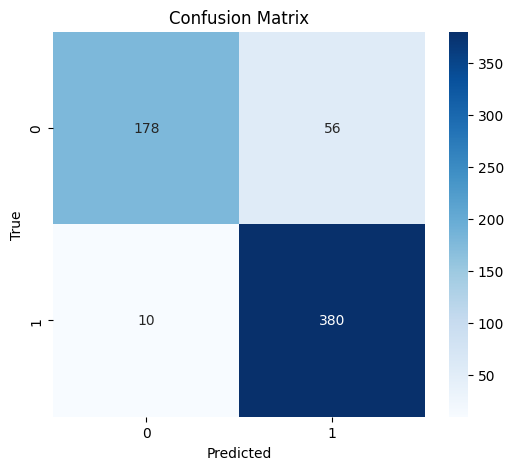

(np.float64(0.8942307692307693),
 0.8914112435881253,
 0.8997779621315635,
 0.8942307692307693,
 array([[178,  56],
        [ 10, 380]]))

In [33]:
hog_weighted_model = BaselineANN(input_size=X_train_hog.shape[1], hidden_size=512, output_size=2).to(device)
hog_weighted_loader = DataLoader(list(zip(torch.tensor(X_train_hog, dtype=torch.float32), torch.tensor(y_train, dtype=torch.long))),
                                batch_size=2048, shuffle=True, num_workers=2)
train_model(hog_weighted_model, hog_weighted_loader, epochs=30, lr=0.001, criterion=weighted_criterion, save_best='best_med_hog_weighted.pth')
evaluate_model(hog_weighted_model, X_test_hog, y_test, num_classes=2, is_raw=False)

In [24]:
np.random.seed(42)
torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


### Nhan xet: Weighted Loss
- Ghi metrics: Accuracy 0.8894, F1 0.8855, Precision 0.8992, Recall 0.8894.
- Weighted loss can bang lop, thuong tang Precision cho lop thieu mau.

### Tong hop nhanh
| Phuong phap | Accuracy | F1 | Precision | Recall |
|---|---:|---:|---:|---:|
| Raw | 0.8878 | 0.8883 | 0.8896 | 0.8878 |
| Augmentation | 0.8446 | 0.8346 | 0.8667 | 0.8446 |
| HOG | 0.8958 | 0.8927 | 0.9035 | 0.8958 |
| CLAHE | 0.8157 | 0.7980 | 0.8553 | 0.8157 |
| CLAHE + HOG | 0.8253 | 0.8153 | 0.8396 | 0.8253 |
| Weighted Loss | 0.8894 | 0.8855 | 0.8992 | 0.8894 |
| HOG + Weighted Loss | 0.8942 | 0.8914 | 0.8998 | 0.8942 |

## Notes

- Record metrics after each feature stage and keep confusion matrices for the report.
- For imbalanced data, prioritize recall but track precision changes.